In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set(style="whitegrid", font_scale=1.2)

# Paths
DATA_PROCESSED = Path("../data/processed")
merged = pd.read_csv(DATA_PROCESSED / "merged_dataset.csv")

print(f"Dataset shape: {merged.shape}")
merged.head()


/tmp/ipykernel_222613/3816256691.py:11: DtypeWarning: Columns (1,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  merged = pd.read_csv(DATA_PROCESSED / "merged_dataset.csv")


Dataset shape: (61330762, 12)


,sample,country,serovar,gene,product,resistance,predicted_mobility,rep_type(s)_x,relaxase_type(s),rep_type(s)_y,size,gc
0,SRR3394933,Chile,Enteritidis,NaN,NaN,NaN,mobilizable,"ColRNAI_rep_cluster_1857,IncL/M",MOBP,-,1549126.0,51.031743
1,SRR3394933,Chile,Enteritidis,NaN,NaN,NaN,mobilizable,"ColRNAI_rep_cluster_1857,IncL/M",MOBP,-,485307.0,52.233329
2,SRR3394933,Chile,Enteritidis,NaN,NaN,NaN,mobilizable,"ColRNAI_rep_cluster_1857,IncL/M",MOBP,-,478455.0,52.516120
3,SRR3394933,Chile,Enteritidis,NaN,NaN,NaN,mobilizable,"ColRNAI_rep_cluster_1857,IncL/M",MOBP,-,405752.0,53.216250
4,SRR3394933,Chile,Enteritidis,NaN,NaN,NaN,mobilizable,"ColRNAI_rep_cluster_1857,IncL/M",MOBP,-,216833.0,54.242666


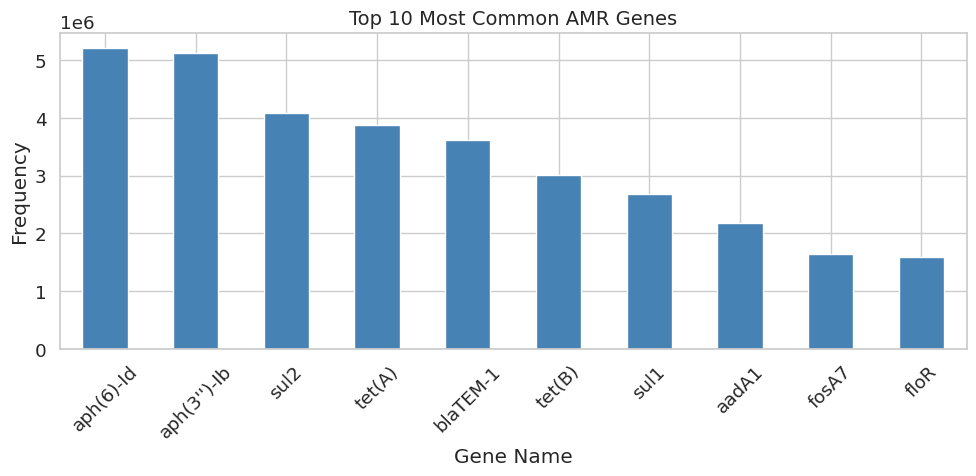

In [2]:
# AMR Gene Frequency

plt.figure(figsize=(10,5))
merged['gene'].value_counts().head(10).plot(kind='bar', color='steelblue')
plt.title("Top 10 Most Common AMR Genes", fontsize=14)
plt.xlabel("Gene Name")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_222613/1713549988.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged, y='predicted_mobility', order=merged['predicted_mobility'].value_counts().index, palette='viridis')


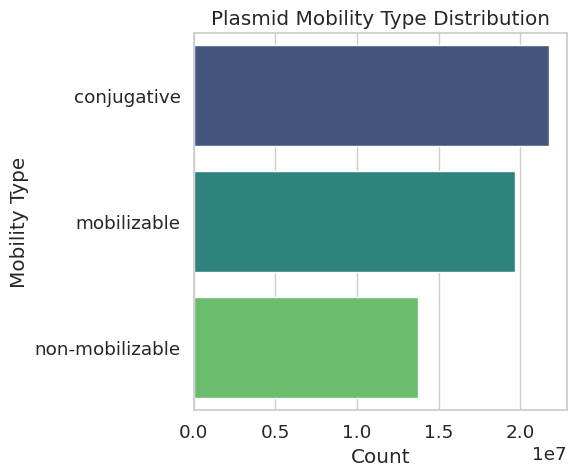

In [3]:
# Plasmid Mobility Distribution

plt.figure(figsize=(6,5))
sns.countplot(data=merged, y='predicted_mobility', order=merged['predicted_mobility'].value_counts().index, palette='viridis')
plt.title("Plasmid Mobility Type Distribution")
plt.xlabel("Count")
plt.ylabel("Mobility Type")
plt.tight_layout()
plt.show()


/tmp/ipykernel_222613/2606339755.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged, x='country', order=merged['country'].value_counts().head(10).index, palette='coolwarm')


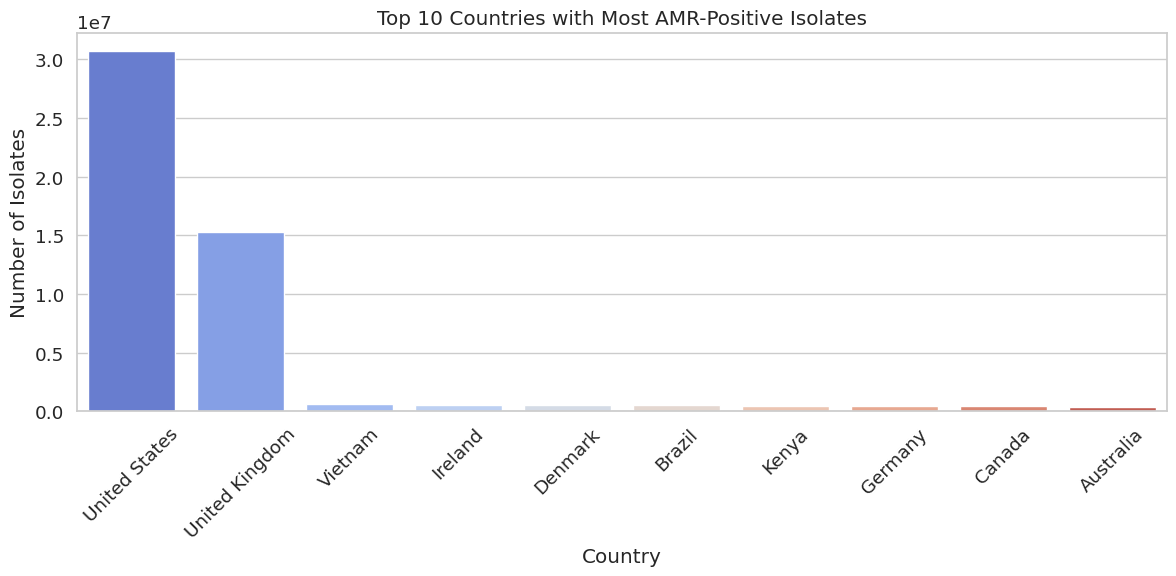

In [4]:
# AMR Gene Diversity by Country or Host

plt.figure(figsize=(12,6))
sns.countplot(data=merged, x='country', order=merged['country'].value_counts().head(10).index, palette='coolwarm')
plt.title("Top 10 Countries with Most AMR-Positive Isolates")
plt.xlabel("Country")
plt.ylabel("Number of Isolates")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


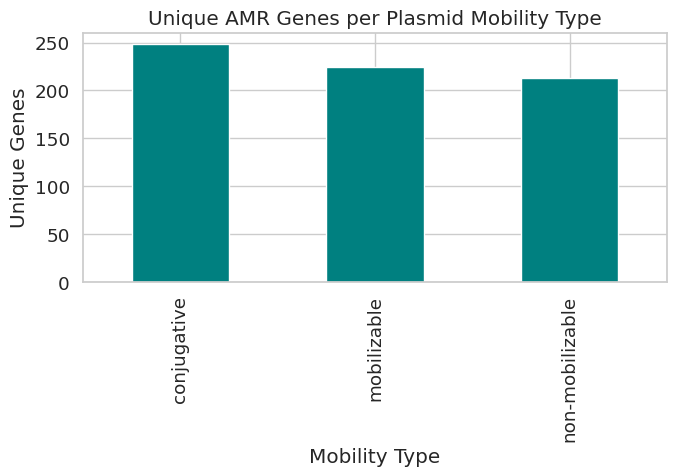

In [5]:
# Relationship Between Mobility and Gene Count

mobility_gene_count = merged.groupby('predicted_mobility')['gene'].nunique().sort_values(ascending=False)
mobility_gene_count.plot(kind='bar', figsize=(7,5), color='teal')
plt.title("Unique AMR Genes per Plasmid Mobility Type")
plt.ylabel("Unique Genes")
plt.xlabel("Mobility Type")
plt.tight_layout()
plt.show()


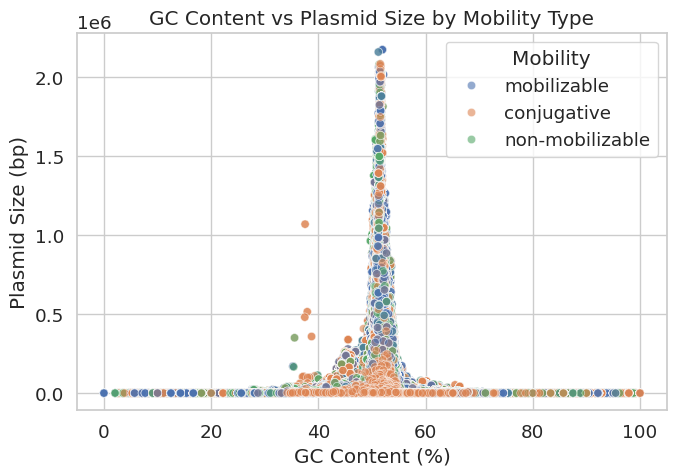

In [6]:
# Correlation Between GC Content and Plasmid Size

plt.figure(figsize=(7,5))
sns.scatterplot(data=merged, x='gc', y='size', hue='predicted_mobility', alpha=0.6)
plt.title("GC Content vs Plasmid Size by Mobility Type")
plt.xlabel("GC Content (%)")
plt.ylabel("Plasmid Size (bp)")
plt.legend(title="Mobility", loc='upper right')
plt.tight_layout()
plt.show()
